In [5]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import KFold
import pickle
from scipy import stats

from imports import *
from config import dir_config, main_config
from src.utils import pmf_utils, glm_hmm_utils
from src.utils.glm_hmm_utils_cv import cross_validation_split


In [7]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_model_name = "no_bias"

best_state = 1
best_state_idx = best_state - 1


In [8]:

with open(Path(processed_dir, f"glm_hmm_off_meds_{glm_hmm_model_name}_final.pkl"), "rb") as f:
    off_meds_glm_hmm_final = pickle.load(f)

with open(Path(processed_dir, f"glm_hmm_on_meds_{glm_hmm_model_name}_final.pkl"), "rb") as f:
    on_meds_glm_hmm_final = pickle.load(f)

off_meds_session_ids = list(off_meds_glm_hmm_final["data"].keys())
on_meds_session_ids = list(on_meds_glm_hmm_final["data"].keys())
glm_hmm_config = on_meds_glm_hmm_final["config"]

In [9]:
filtered_data = pd.read_csv(Path(processed_dir, "processed_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_accu_60.csv"), index_col=None)

In [10]:
# Getting indices of on and off treatment from same subject in processed metadata
subject_treatment_idx = pd.DataFrame(columns=["subject", "off", "on"])
treatment_idx = pd.DataFrame(columns=["subject", "off", "on"])

for idx, sub in enumerate(processed_metadata["subject_id"].unique()):
    sub_df = processed_metadata.loc[processed_metadata["subject_id"] == sub]
    subject_treatment_idx.loc[idx] = [sub, sub_df.loc[sub_df["treatment"] == "OFF"].index[0], sub_df.loc[sub_df["treatment"] == "ON"].index[0]]

    if np.sum(np.isnan(sub_df["trem_by_brady"])) == 0:
        # put off treatment first column and on treatment second column one row at a time
        treatment_idx.loc[idx] = [sub, sub_df.loc[sub_df["treatment"] == "OFF"].index[0], sub_df.loc[sub_df["treatment"] == "ON"].index[0]]


original_all_subjects = ["CG", "COH", "MBY", "DP", "FUR", "LBR", "MAR", "SMI", "RW", "SGA"]
original_trem_subjects = ["DP", "FUR", "LBR", "MAR", "SMI"]
original_brady_subjects = ["CG", "COH", "MBY", "RW", "SGA"]

new_trem_subjects = np.sort(processed_metadata.loc[processed_metadata["trem_vs_brady_type"] == "tremor"]["subject_id"].unique())
new_brady_subjects = np.sort(processed_metadata.loc[processed_metadata["trem_vs_brady_type"] == "bradykinetic"]["subject_id"].unique())
new_intermediate_subjects = np.sort(processed_metadata.loc[processed_metadata["trem_vs_brady_type"] == "intermediate"]["subject_id"].unique())
print(f"New tremor_subjects: {len(new_trem_subjects)} \t {new_trem_subjects}")
print(f"New brady_subjects: {len(new_brady_subjects)} \t{new_brady_subjects}")
print(f"New intermediate_subjects: {len(new_intermediate_subjects)} \t{new_intermediate_subjects}")

new_all_subjects = subject_treatment_idx["subject"].unique()
new_subtype_subjects = treatment_idx["subject"].unique()
# print(f"New all_subjects: {new_all_subjects}")
# print(f"New subtype_subjects: {new_subtype_subjects}")

New tremor_subjects: 11 	 ['P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P3' 'P31' 'P32' 'P6' 'P7']
New brady_subjects: 10 	['P1' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34' 'P4' 'P9']
New intermediate_subjects: 1 	['P24']


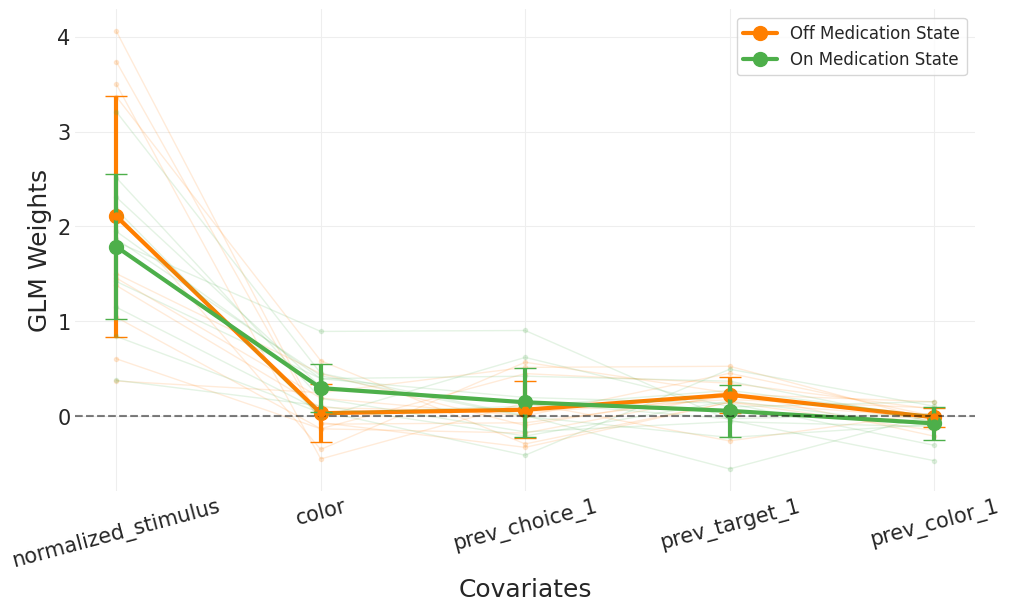

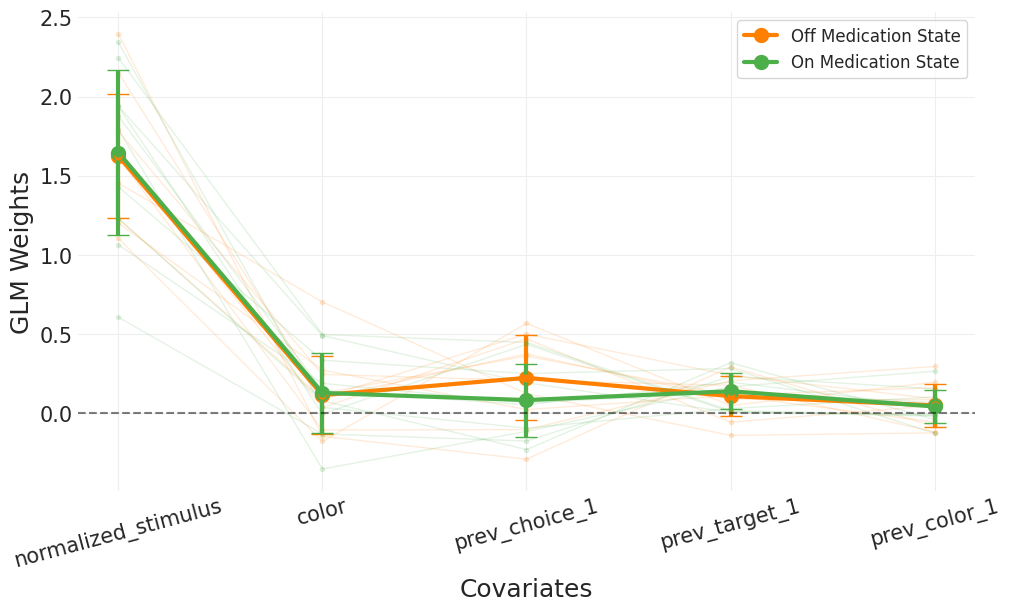

In [12]:

group_patients = new_trem_subjects.tolist()

for patient_group in [new_trem_subjects, new_brady_subjects]:

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))  # Wider figure for better spacing

    # Off Medication States
    colors = ["#ff7f00"]  # Colors for the states
    labels = ["Off Medication State"]
    glm_weights_session_wise = []
    for _, patient_id in enumerate(patient_group):
        session_id = patient_id + "_OFF"
        model = off_meds_glm_hmm_final["model"]["models"][session_id]
        glm_weights = -np.array(model.observations.params).reshape(best_state, -1)
        glm_weights_session_wise.append(glm_weights)
        for k in range(best_state):
            ax.plot(np.arange(len(glm_hmm_config["model_features"])), glm_weights[k], marker="o", color=colors[k], linestyle="-", markersize=3, lw=1, alpha=0.15)
    for k in range(best_state):
        mean_weights = np.mean(np.array(glm_weights_session_wise), axis=0)
        std_weights = np.std(np.array(glm_weights_session_wise), axis=0)
        ax.errorbar(np.arange(len(glm_hmm_config["model_features"])), mean_weights[k], yerr=std_weights[k], fmt="o", color=colors[k], markersize=5, lw=1.5, capsize=8, elinewidth=3)
        ax.plot(np.arange(len(glm_hmm_config["model_features"])), np.mean(np.array(glm_weights_session_wise), axis=0)[k], marker="o", color=colors[k], linestyle="-", markersize=10, lw=3, label=labels[k])

    # On Medication States
    colors = ["#4daf4a"]  # Colors for the states
    labels = ["On Medication State"]
    glm_weights_session_wise = []
    for _, patient_id in enumerate(patient_group):
        session_id = patient_id + "_ON"
        model = on_meds_glm_hmm_final["model"]["models"][session_id]
        glm_weights = -np.array(model.observations.params).reshape(best_state, -1)
        glm_weights_session_wise.append(glm_weights)
        for k in range(best_state):
            ax.plot(np.arange(len(glm_hmm_config["model_features"])), glm_weights[k], marker="o", color=colors[k], linestyle="-", markersize=3, lw=1, alpha=0.15)
    for k in range(best_state):
        mean_weights = np.mean(np.array(glm_weights_session_wise), axis=0)
        std_weights = np.std(np.array(glm_weights_session_wise), axis=0)
        ax.errorbar(np.arange(len(glm_hmm_config["model_features"])), mean_weights[k], yerr=std_weights[k], fmt="o", color=colors[k], markersize=5, lw=1.5, capsize=8, elinewidth=3)
        ax.plot(np.arange(len(glm_hmm_config["model_features"])), np.mean(np.array(glm_weights_session_wise), axis=0)[k], marker="o", color=colors[k], linestyle="-", markersize=10, lw=3, label=labels[k])


    # Formatting
    ax.tick_params(axis="y", labelsize=10)
    ax.set_ylabel("GLM Weights", fontsize=18)
    ax.set_xlabel("Covariates", fontsize=18)
    ax.set_xticks(range(len(glm_hmm_config["model_features"])))
    # ax.set_ylim([-2, 5])
    ax.set_xticklabels(glm_hmm_config["model_features"], fontsize=15, rotation=15)
    # ax.set_yticks(np.arange(-2, 8, 2))
    ax.tick_params(axis="y", which="major", labelsize=15)
    ax.axhline(y=0, color="k", alpha=0.5, ls="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(fontsize=12, loc="upper right")

    plt.show()



Significance Results:
normalized_stimulus: p=0.3977, corrected p=0.4279 
color: p=0.0780, corrected p=0.1951 
prev_choice_1: p=0.4279, corrected p=0.4279 
prev_target_1: p=0.0547, corrected p=0.1951 
prev_color_1: p=0.3578, corrected p=0.4279 


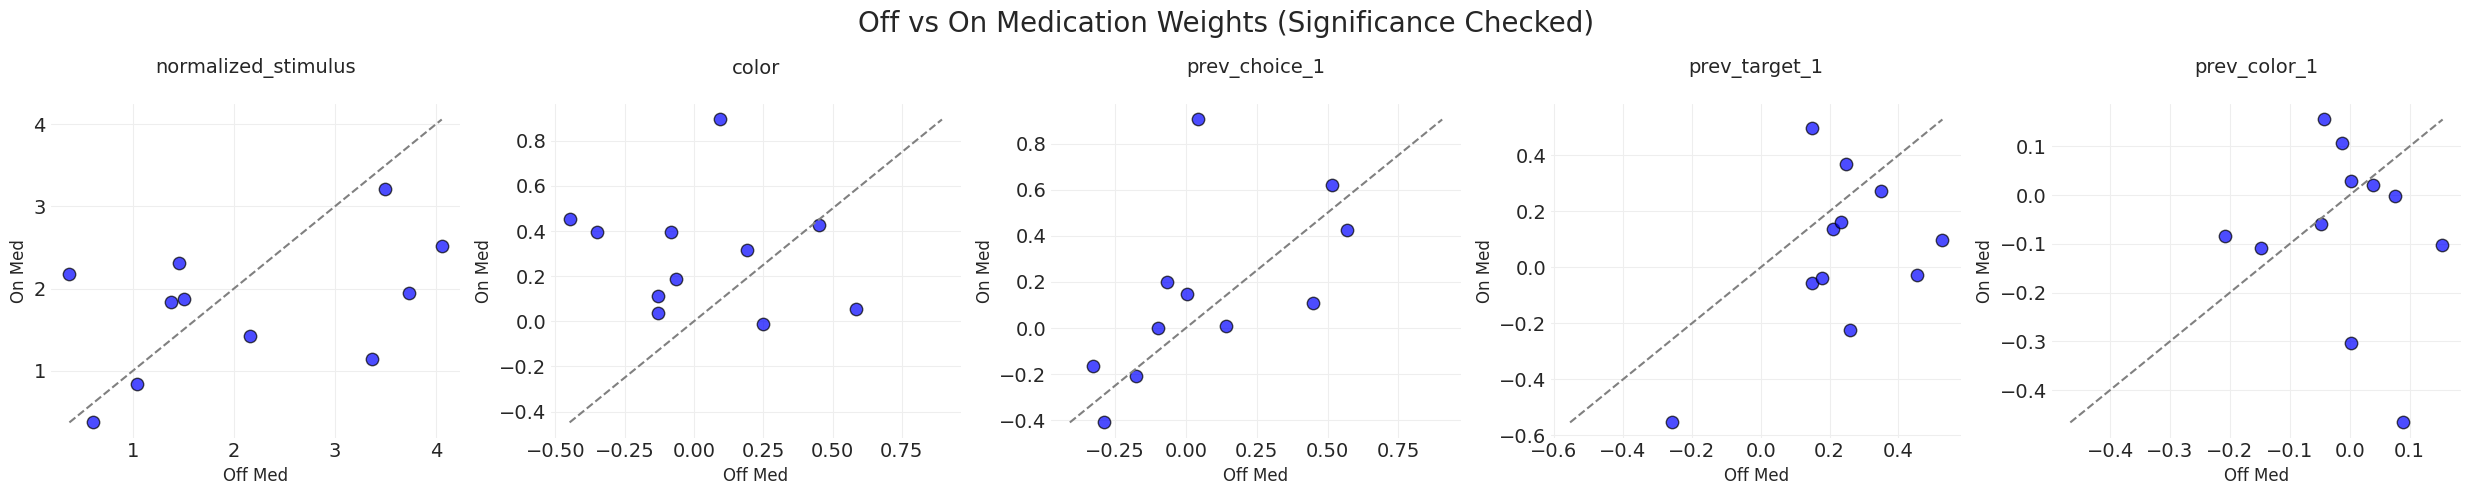


Significance Results:
normalized_stimulus: p=0.9239, corrected p=0.9239 
color: p=0.9104, corrected p=0.9239 
prev_choice_1: p=0.2185, corrected p=0.9239 
prev_target_1: p=0.6571, corrected p=0.9239 
prev_color_1: p=0.9048, corrected p=0.9239 


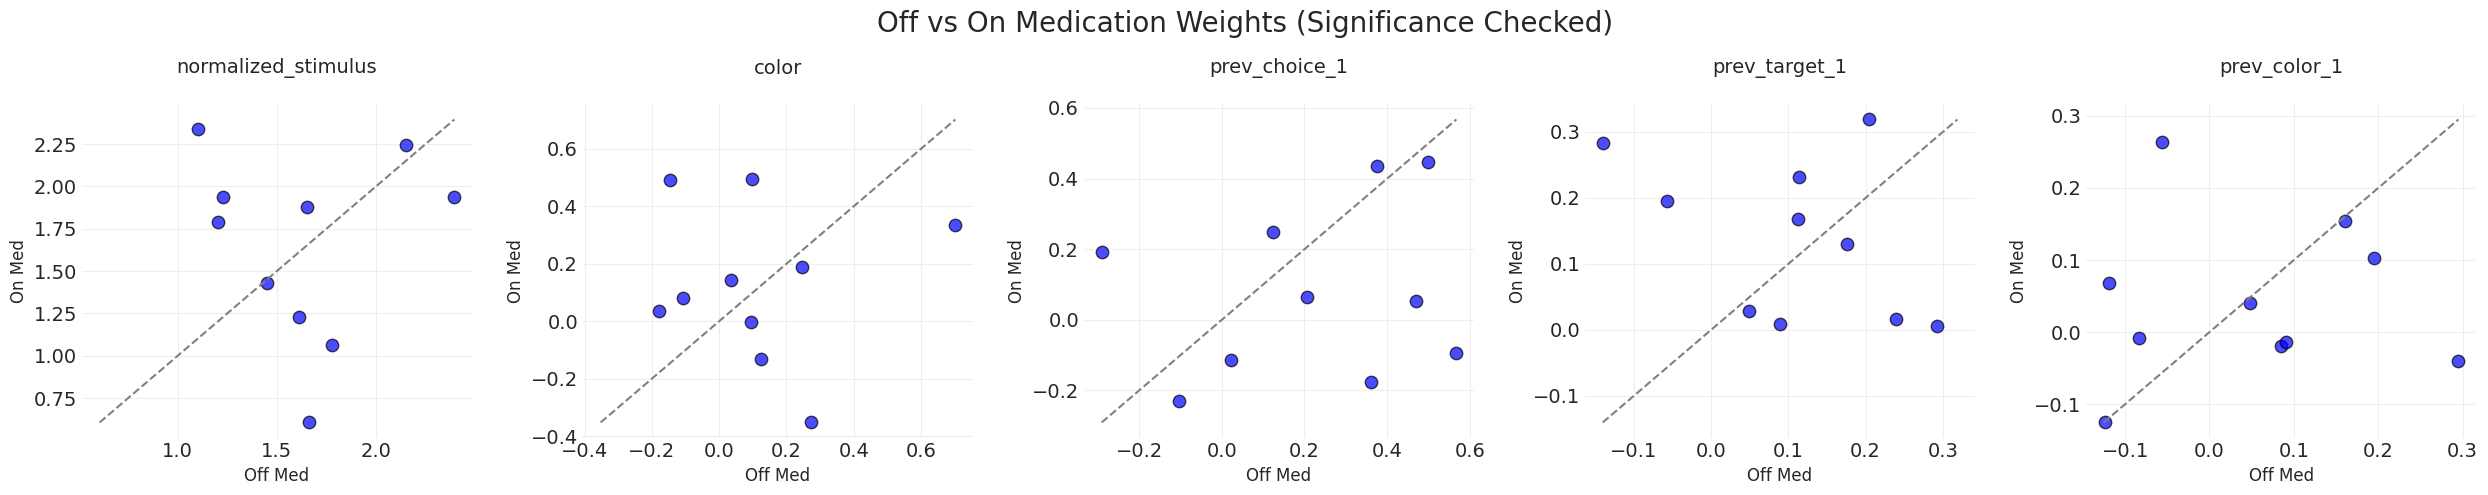

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

# Define covariate labels
covariates = glm_hmm_config["model_features"]

num_covariates = len(covariates)

for patient_group in [new_trem_subjects, new_brady_subjects]:
    # Collect Off and On weights
    off_weights_all = []
    on_weights_all = []

    for patient_id in patient_group:
        # Off medication
        session_id_off = patient_id + "_OFF"
        model_off = off_meds_glm_hmm_final["model"]["models"][session_id_off]
        glm_weights_off = -np.array(model_off.observations.params).reshape(best_state, -1)
        mean_off = np.mean(glm_weights_off, axis=0)
        off_weights_all.append(mean_off)

        # On medication
        session_id_on = patient_id + "_ON"
        model_on = on_meds_glm_hmm_final["model"]["models"][session_id_on]
        glm_weights_on = -np.array(model_on.observations.params).reshape(best_state, -1)
        mean_on = np.mean(glm_weights_on, axis=0)
        on_weights_all.append(mean_on)

    off_weights_all = np.array(off_weights_all)
    on_weights_all = np.array(on_weights_all)

    # Statistical test: Paired t-test for each covariate
    p_values = []
    for idx in range(num_covariates):
        _, p = ttest_rel(off_weights_all[:, idx], on_weights_all[:, idx])
        p_values.append(p)

    p_values = np.array(p_values)

    # Multiple comparison correction (FDR)
    reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

    # Print results
    print("\nSignificance Results:")
    for idx, cov in enumerate(covariates):
        sig_mark = "***" if reject[idx] else ""
        print(f"{cov}: p={p_values[idx]:.4f}, corrected p={p_corrected[idx]:.4f} {sig_mark}")

    # Scatter plots
    fig, axs = plt.subplots(1, num_covariates, figsize=(5 * num_covariates, 5))
    fig.suptitle("Off vs On Medication Weights (Significance Checked)", fontsize=20)

    for idx, cov in enumerate(covariates):
        ax = axs[idx] if num_covariates > 1 else axs
        x = off_weights_all[:, idx]
        y = on_weights_all[:, idx]

        ax.scatter(x, y, color="blue", alpha=0.7, edgecolor="k", s=80)

        # Diagonal
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], color="gray", linestyle="--")

        ax.set_title(f"{cov}\n{'*' if reject[idx] else ''}", fontsize=14)
        ax.set_xlabel("Off Med", fontsize=12)
        ax.set_ylabel("On Med", fontsize=12)

    plt.tight_layout()
    plt.show()



Significance Results (Wilcoxon Signed-Rank Test):
normalized_stimulus: p=0.5771, corrected p=0.7002 
color: p=0.1230, corrected p=0.3076 
prev_choice_1: p=0.6377, corrected p=0.7002 
prev_target_1: p=0.0674, corrected p=0.3076 
prev_color_1: p=0.7002, corrected p=0.7002 


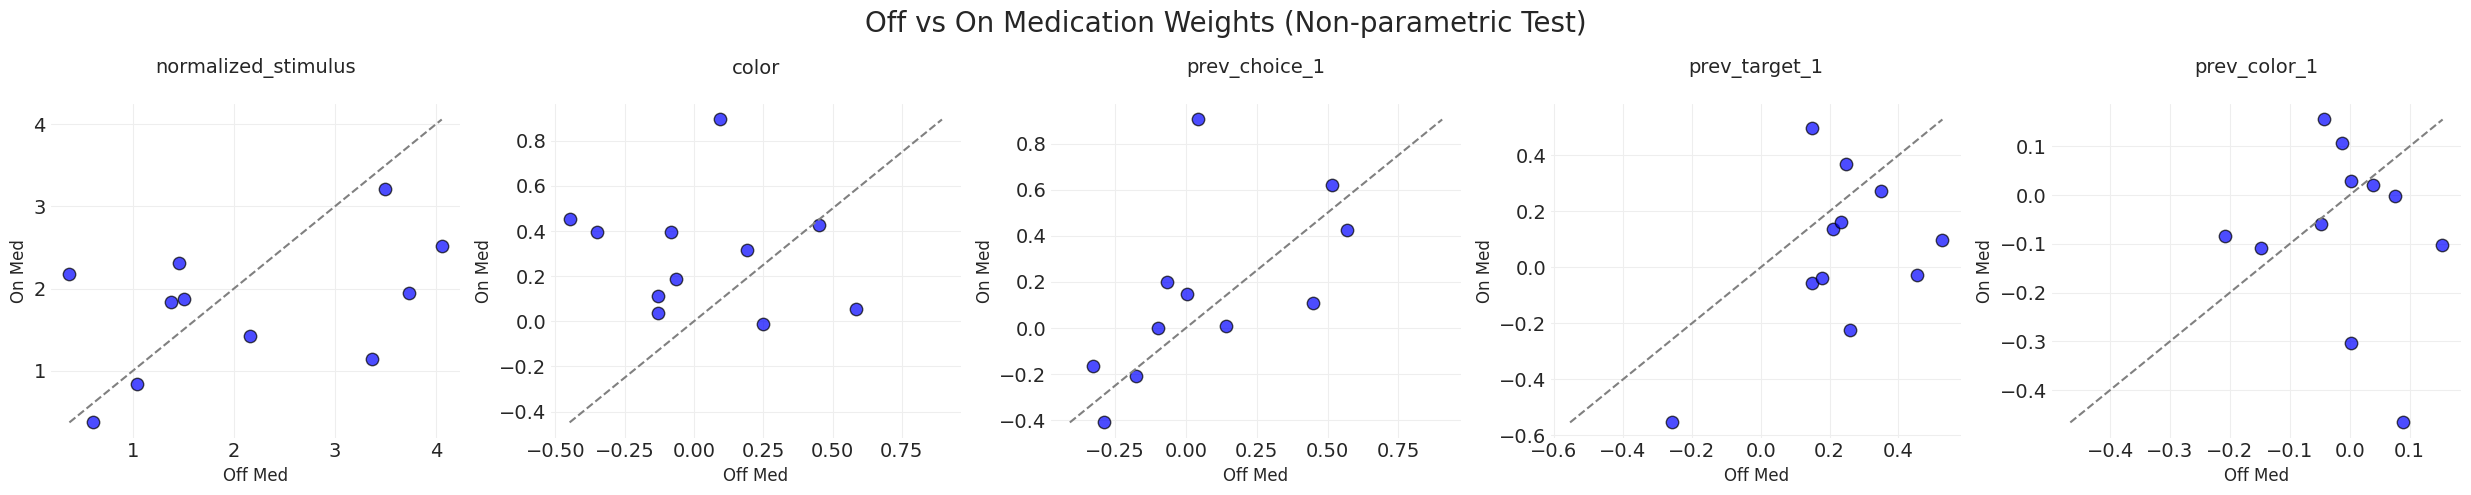


Significance Results (Wilcoxon Signed-Rank Test):
normalized_stimulus: p=1.0000, corrected p=1.0000 
color: p=0.8457, corrected p=1.0000 
prev_choice_1: p=0.1934, corrected p=0.9668 
prev_target_1: p=0.6953, corrected p=1.0000 
prev_color_1: p=0.5566, corrected p=1.0000 


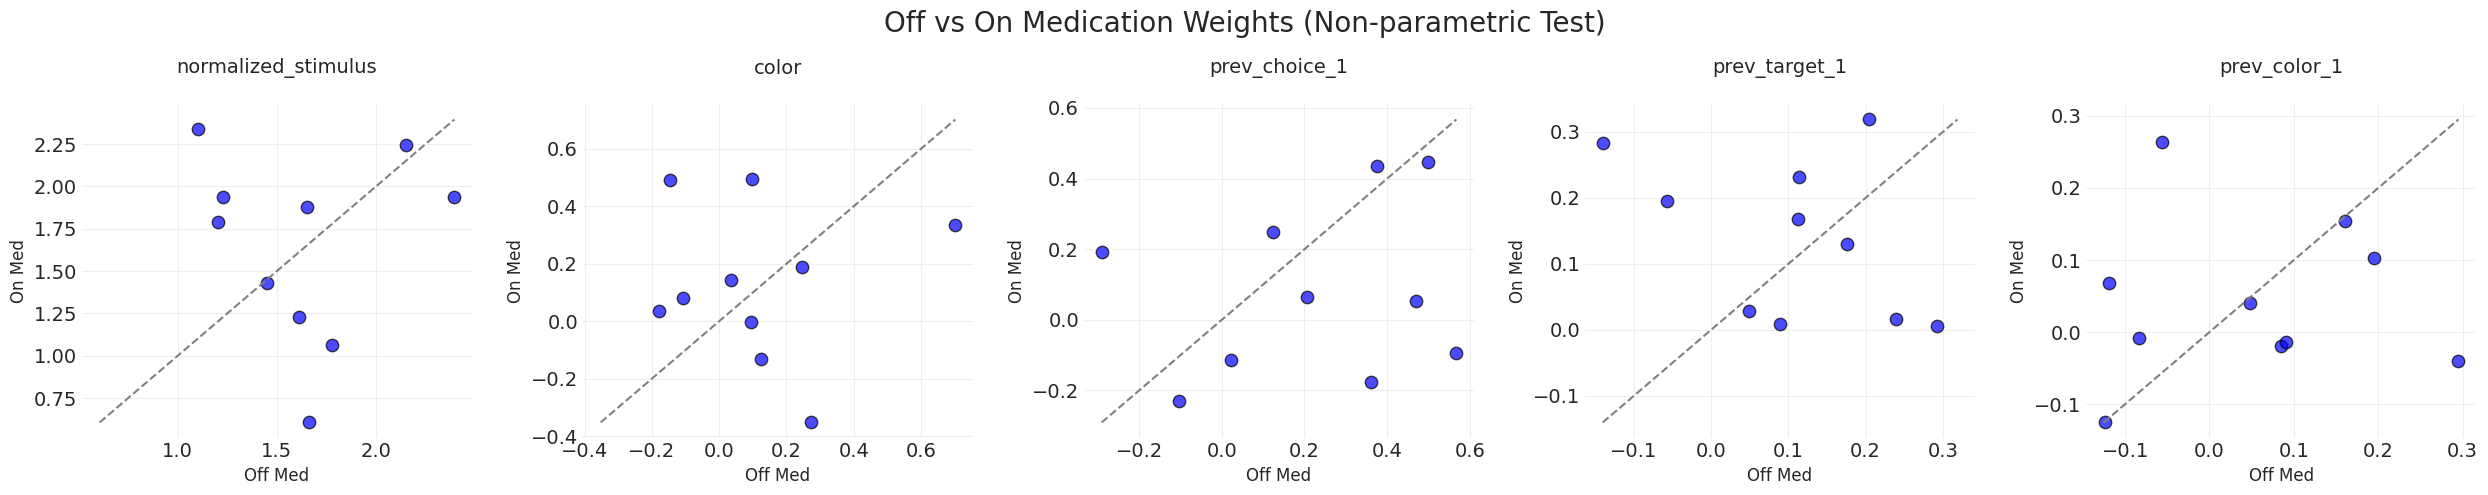

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Define covariate labels
covariates = glm_hmm_config["model_features"]

num_covariates = len(covariates)

for patient_group in [new_trem_subjects, new_brady_subjects]:
    # Collect Off and On weights
    off_weights_all = []
    on_weights_all = []

    for patient_id in patient_group:
        # Off medication
        session_id_off = patient_id + "_OFF"
        model_off = off_meds_glm_hmm_final["model"]["models"][session_id_off]
        glm_weights_off = -np.array(model_off.observations.params).reshape(best_state, -1)
        mean_off = np.mean(glm_weights_off, axis=0)
        off_weights_all.append(mean_off)

        # On medication
        session_id_on = patient_id + "_ON"
        model_on = on_meds_glm_hmm_final["model"]["models"][session_id_on]
        glm_weights_on = -np.array(model_on.observations.params).reshape(best_state, -1)
        mean_on = np.mean(glm_weights_on, axis=0)
        on_weights_all.append(mean_on)

    off_weights_all = np.array(off_weights_all)
    on_weights_all = np.array(on_weights_all)

    # Non-parametric test: Wilcoxon signed-rank test
    p_values = []
    for idx in range(num_covariates):
        try:
            stat, p = wilcoxon(off_weights_all[:, idx], on_weights_all[:, idx])
        except ValueError:
            # Happens if all differences are zero → Wilcoxon cannot compute
            p = 1.0
        p_values.append(p)

    p_values = np.array(p_values)

    # Multiple comparison correction (FDR)
    reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

    # Print results
    print("\nSignificance Results (Wilcoxon Signed-Rank Test):")
    for idx, cov in enumerate(covariates):
        sig_mark = "***" if reject[idx] else ""
        print(f"{cov}: p={p_values[idx]:.4f}, corrected p={p_corrected[idx]:.4f} {sig_mark}")

    # Scatter plots
    fig, axs = plt.subplots(1, num_covariates, figsize=(5 * num_covariates, 5))
    fig.suptitle("Off vs On Medication Weights (Non-parametric Test)", fontsize=20)

    for idx, cov in enumerate(covariates):
        ax = axs[idx] if num_covariates > 1 else axs
        x = off_weights_all[:, idx]
        y = on_weights_all[:, idx]

        ax.scatter(x, y, color="blue", alpha=0.7, edgecolor="k", s=80)

        # Diagonal
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], color="gray", linestyle="--")

        ax.set_title(f"{cov}\n{'*' if reject[idx] else ''}", fontsize=14)
        ax.set_xlabel("Off Med", fontsize=12)
        ax.set_ylabel("On Med", fontsize=12)

    plt.tight_layout()
    plt.show()



Significance Results for OFF Medication: Tremor vs Bradykinesia:
Stimulus: p=0.2133, corrected p=0.5605 
Color: p=0.5268, corrected p=0.6321 
Bias: p=0.6902, corrected p=0.6902 
Prev Choice 1: p=0.3736, corrected p=0.5605 
Prev Target 1: p=0.1120, corrected p=0.5605 
Prev Color 1: p=0.3109, corrected p=0.5605 


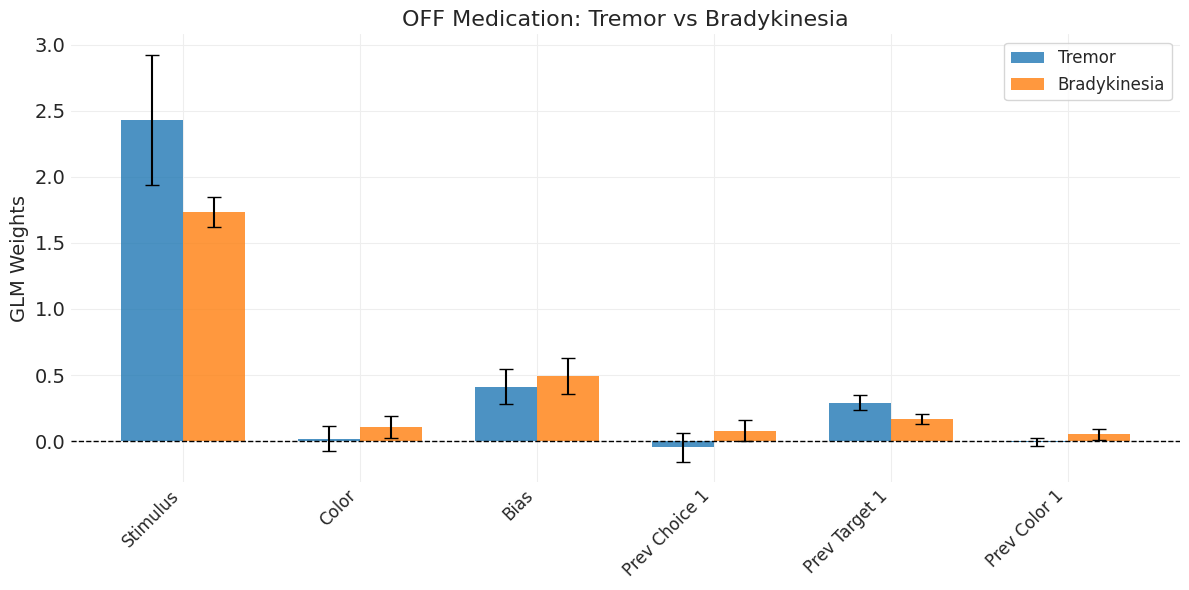


Significance Results for ON Medication: Tremor vs Bradykinesia:
Stimulus: p=0.4938, corrected p=0.6612 
Color: p=0.1537, corrected p=0.4611 
Bias: p=0.3694, corrected p=0.6612 
Prev Choice 1: p=0.9776, corrected p=0.9776 
Prev Target 1: p=0.5510, corrected p=0.6612 
Prev Color 1: p=0.0997, corrected p=0.4611 


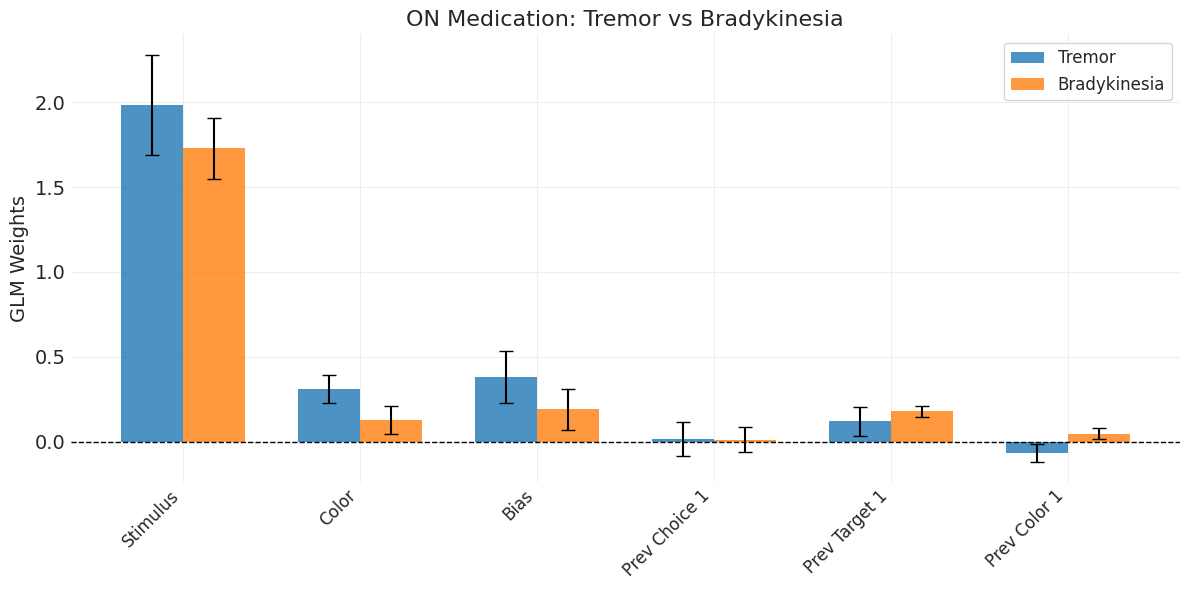

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Define covariate labels
covariates = ["Stimulus", "Color", "Bias"] + [f"Prev Choice {i + 1}" for i in range(n_trial_back)] + [f"Prev Target {i + 1}" for i in range(n_trial_back)] + [f"Prev Color {i + 1}" for i in range(n_trial_back)]

num_covariates = len(covariates)


# Function to collect weights for a group and condition
def collect_group_weights(patient_group, condition):
    weights_all = []
    for patient_id in patient_group:
        session_id = f"{patient_id}_{condition}"
        if condition == "OFF":
            model = off_meds_glm_hmm_final["model"]["models"][session_id]
        else:
            model = on_meds_glm_hmm_final["model"]["models"][session_id]
        glm_weights = -np.array(model.observations.params).reshape(best_state, -1)
        mean_weights = np.mean(glm_weights, axis=0)  # Average across states
        weights_all.append(mean_weights)
    return np.array(weights_all)


# Collect data
off_trem = collect_group_weights(new_trem_subjects, "OFF")
off_brady = collect_group_weights(new_brady_subjects, "OFF")
on_trem = collect_group_weights(new_trem_subjects, "ON")
on_brady = collect_group_weights(new_brady_subjects, "ON")


# ----------------------------
# Function to plot comparison
# ----------------------------
def plot_group_bar(data1, data2, title, group1_label, group2_label):
    # Perform independent t-tests
    p_values = []
    for idx in range(num_covariates):
        _, p = ttest_ind(data1[:, idx], data2[:, idx], equal_var=False)
        p_values.append(p)

    p_values = np.array(p_values)

    # Multiple comparison correction (FDR)
    reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

    # Print results
    print(f"\nSignificance Results for {title}:")
    for idx, cov in enumerate(covariates):
        sig_mark = "***" if reject[idx] else ""
        print(f"{cov}: p={p_values[idx]:.4f}, corrected p={p_corrected[idx]:.4f} {sig_mark}")

    # Compute means and SEM
    means1 = np.mean(data1, axis=0)
    sem1 = np.std(data1, axis=0) / np.sqrt(data1.shape[0])
    means2 = np.mean(data2, axis=0)
    sem2 = np.std(data2, axis=0) / np.sqrt(data2.shape[0])

    # Bar plot
    x = np.arange(num_covariates)
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(12, num_covariates * 1.5), 6))
    ax.bar(x - width / 2, means1, width, yerr=sem1, capsize=5, label=group1_label, color="#1f77b4", alpha=0.8)
    ax.bar(x + width / 2, means2, width, yerr=sem2, capsize=5, label=group2_label, color="#ff7f0e", alpha=0.8)

    # Add significance stars
    for idx in range(num_covariates):
        if reject[idx]:
            ax.text(x[idx], max(means1[idx] + sem1[idx], means2[idx] + sem2[idx]) + 0.2, "*", ha="center", va="bottom", fontsize=18, color="red")

    ax.set_xticks(x)
    ax.set_xticklabels(covariates, rotation=45, ha="right", fontsize=12)
    ax.set_ylabel("GLM Weights", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(fontsize=12)
    ax.axhline(0, color="k", linestyle="--", linewidth=1)

    plt.tight_layout()
    plt.show()


# ----------------------------
# OFF Medication
# ----------------------------
plot_group_bar(off_trem, off_brady, "OFF Medication: Tremor vs Bradykinesia", "Tremor", "Bradykinesia")

# ----------------------------
# ON Medication
# ----------------------------
plot_group_bar(on_trem, on_brady, "ON Medication: Tremor vs Bradykinesia", "Tremor", "Bradykinesia")
